In [7]:
%load_ext autoreload
%autoreload 2
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import xarray as xr
import numpy as np
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 

In [9]:
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)


xarray: 2025.10.1
xgcm: 0.9.0


In [10]:
import xbudget
xbudget_dict = xbudget.load_yaml("ECCOV4r4.yaml").copy()

In [11]:
ds

<xarray.Dataset> Size: 217MB
Dimensions:      (time_bounds: 3, tile: 13, j: 90, i: 90, time: 2, k: 50,
                  i_g: 90, j_g: 90, k_l: 50, k_p1: 51, k_u: 50, nb: 4, nv: 2)
Coordinates: (12/43)
  * time_bounds  (time_bounds) datetime64[ns] 24B 1993-01-01 ... 1993-03-01
  * tile         (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j            (j) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * i            (i) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time         (time) datetime64[ns] 16B 1993-01-16T12:00:00 1993-02-15
  * k            (k) int32 200B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
    ...           ...
    YG           (tile, j_g, i_g) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    Z            (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
    Z_bnds       (k, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    Zl           (k_l) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
    Zp1          (k_p1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
    Zu           (k_u) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
Dimensions without coordinates: nb, nv
Data variables:
    ETAN_bounds  (time_bounds, tile, j, i) float32 1MB dask.array<chunksize=(3, 13, 90, 90), meta=np.ndarray>
    oceFWflx     (time, tile, j, i) float32 842kB dask.array<chunksize=(1, 13, 90, 90), meta=np.ndarray>
    UVELMASS     (time, k, tile, j, i_g) float32 42MB dask.array<chunksize=(1, 25, 13, 45, 45), meta=np.ndarray>
    VVELMASS     (time, k, tile, j_g, i) float32 42MB dask.array<chunksize=(1, 25, 13, 45, 45), meta=np.ndarray>
    WVELMASS     (time, k_l, tile, j, i) float32 42MB dask.array<chunksize=(1, 50, 13, 45, 45), meta=np.ndarray>
Attributes: (12/58)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on the curvilinear lat-l...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    references:                      ECCO Consortium, Fukumori, I., Wang, O.,...
    source:                          The ECCO V4r4 state estimate was produce...
    standard_name_vocabulary:        NetCDF Climate and Forecast (CF) Metadat...
    summary:                         This dataset provides geometric paramete...
    title:                           ECCO Geometry Parameters for the Lat-Lon...
    uuid:                            87ff7d24-86e5-11eb-9c5f-f8f21e2ee3e0

In [13]:
ds = xr.open_mfdataset("./data/ECCO_budget_terms.zarr").chunk({"k_l":-1, "tile":-1, "time_bounds":-1})
ds["time"].attrs["c_grid_axis_shift"] = 0.0
ds["time_bounds"].attrs["c_grid_axis_shift"] = -0.5

grid = construct_grid(ds)

In [14]:
ecco_budget = xr.open_mfdataset("./data/ECCO_budget_terms.zarr").chunk({"k_l":-1, "tile":-1}).fillna(0.0)


In [17]:
ecco_budget = xr.open_mfdataset("./data/ECCO_budget_terms.zarr").chunk({"k_l":-1, "tile":-1}).fillna(0.0)
ecco_budget["time"].attrs["c_grid_axis_shift"] = 0.0
ecco_budget["time_bounds"].attrs["c_grid_axis_shift"] = -0.5
grid = construct_grid(ecco_budget)

# xbudget.collect_budgets(grid, xbudget_dict)
# import json
# print(json.dumps(xbudget_dict['mass'], sort_keys=True, indent=4))

In [18]:
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})
dt = dt.dt.total_seconds() #nice! 

In [19]:
def diff_1d_flux_llc90(w_flux, geometry):
    w_flux = w_flux.transpose('time','tile','k_l','j','i')
    w_flux_padded = w_flux.pad(pad_width={'k_l': (0, 1)}, 
                               mode='constant', 
                               constant_values=0) #all fluxes are zero at the bottom
    
    dw = w_flux_padded.diff("k_l")
    dw = dw.rename({'k_l': 'k'}).assign_coords(k=geometry['k'])
    return dw

    
def calc_1d_flux_convergence(w_flux, geometry):
    return diff_1d_flux_llc90(w_flux, geometry)
    
def calc_2d_flux_convergence(u_flux, v_flux, geometry):
    dudv = diff_2d_flux_llc90(u_flux, v_flux, geometry)

    flux_conv = -(dudv["X"] + dudv["Y"])
    
    if ("time" in flux_conv.coords):
        return flux_conv.transpose('time','tile','k','j','i')
    else:
        return flux_conv.transpose('tile','k','j','i')

def diff_2d_flux_llc90(u_flux, v_flux, geometry):
    """
    Manually compute the 2D divergence of fluxes on the LLC90 grid.
    This function mimics xgcm.diff_2d_vector but explicitly handles
    face connections and padding for the LLC topology.

    Parameters
    ----------
    flux_vector : dict
        A dictionary with keys 'X' and 'Y' containing xarray.DataArray
        objects for the U-flux (on i-face) and V-flux (on j-face),
        respectively.

    Returns
    -------
    dict
        A dictionary with keys 'X' and 'Y' for the differenced U and V
        flux components on C-grid points. You can combine these to get
        the divergence: dU/dx + dV/dy.
    """

    # ------------------------------------------------------------------------
    # 1) Pad arrays by one cell in the face dimension to prepare for diff
    # ------------------------------------------------------------------------

    # Pad u_flux along the i_g dimension (add a column of NaNs at the end)
    u_flux_padded = u_flux.pad(
        pad_width={'i_g': (0, 1)},
        mode='constant', constant_values=np.nan
    )
    # Ensure u_padded has a single chunk along i_g for unambiguous padding
    u_flux_padded = u_flux_padded.chunk({'i_g': u_flux_padded.sizes['i_g'] + 1})

    # Pad v_flux along the j_g dimension (add a row of NaNs at the end)
    v_flux_padded = v_flux.pad(
        pad_width={'j_g': (0, 1)},
        mode='constant', constant_values=np.nan
    )
    # Ensure v_padded has a single chunk along j_g
    v_flux_padded = v_flux_padded.chunk({'j_g': v_flux_padded.sizes['j_g'] + 1})

    # ------------------------------------------------------------------------
    # 2) Helper function to replace padded boundary values
    # ------------------------------------------------------------------------
    def da_replace_at_indices(da,indexing_dict,replace_values):
        # replace values in xarray DataArray using locations specified by indexing_dict
        array_data = da.data
        indexing_dict_bynum = {}
        for axis,dim in enumerate(da.dims):
            if dim in indexing_dict.keys():
                indexing_dict_bynum = {**indexing_dict_bynum,**{axis:indexing_dict[dim]}}
        ndims = len(array_data.shape)
        indexing_list = [':']*ndims
        for axis in indexing_dict_bynum.keys():
            indexing_list[axis] = indexing_dict_bynum[axis]
        indexing_str = ",".join(indexing_list)

        # using exec isn't ideal, but this works for both NumPy and Dask arrays
        exec('array_data['+indexing_str+'] = replace_values')

        return da

    # u flux padding
    for tile in range(0,3):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+3,i_g=0).data)
    for tile in range(3,6):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              v_flux.isel(tile=12-tile,j_g=0,i=slice(None,None,-1)).data)
    u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':'6','i_g':'-1'},\
                                          u_flux.isel(tile=7,i_g=0).data)
    for tile in range(7,9):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
    for tile in range(10,12):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)

    # v flux padding
    for tile in range(0,2):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'2','j_g':'-1'},\
                                          u_flux.isel(tile=6,j=slice(None,None,-1),i_g=0).data)
    for tile in range(3,6):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'6','j_g':'-1'},\
                                          u_flux.isel(tile=10,j=slice(None,None,-1),i_g=0).data)
    for tile in range(7,10):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+3,j_g=0).data)
    for tile in range(10,13):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              u_flux.isel(tile=12-tile,j=slice(None,None,-1),i_g=0).data)

    # ------------------------------------------------------------------------
    # 5) Compute the finite differences on padded arrays
    # ------------------------------------------------------------------------

    # Difference along i_g then rename to i (C-point)
    du = u_flux_padded.diff('i_g')
    du = du.rename({'i_g': 'i'}).assign_coords(i=geometry['i'])

    # Difference along j_g then rename to j
    dv = v_flux_padded.diff('j_g')
    dv = dv.rename({'j_g': 'j'}).assign_coords(j=geometry['j'])

    # Return a dict matching xgcm's diff_2d_vector output
    return {'X': du, 'Y': dv}

def calc_2d_flux_convergence_ghost(grid, u_flux, v_flux):
    dudv = diff_2d_flux_llc90_ghost(grid, u_flux, v_flux)

    flux_conv = -(dudv["X"] + dudv["Y"])
    
    if ("time" in flux_conv.coords):
        return flux_conv.transpose('time','tile','k','j','i')
    else:
        return flux_conv.transpose('tile','k','j','i')

        
import numpy as np
import xarray as xr

def diff_2d_flux_llc90_ghost(grid, Fx, Fy, face_dim=None):
    if face_dim is None:
        keys = list(grid._face_connections.keys())
        if len(keys) != 1:
            raise ValueError("Provide face_dim when grid has multiple face-connection keys.")
        face_dim = keys[0]

    ds = grid._ds

    def _center_dim(ax):
        return grid.axes[ax].coords["center"]

    def _stag_dim(ax, da):
        c = [c for pos, c in grid.axes[ax].coords.items() if pos != "center" and c in da.dims]
        if len(c) != 1:
            raise ValueError("Flux difference inconsistent with finite volume discretization.")
        return c[0]

    Xc, Yc = _center_dim("X"), _center_dim("Y")
    Xs, Ys = _stag_dim("X", Fx), _stag_dim("Y", Fy)

    xs_new = int(Fx[Xs].isel({Xs: -1}).values) + 1
    ys_new = int(Fy[Ys].isel({Ys: -1}).values) + 1

    tiles = Fx[face_dim].values

    def ghost_X(t):
        t = int(t)
        if 0 <= t <= 2:
            g = Fx.sel({face_dim: t + 3}).isel({Xs: 0})
        elif 3 <= t <= 5:
            g = Fy.sel({face_dim: 12 - t}).isel({Ys: 0, Xc: slice(None, None, -1)}).rename({Xc: Yc}).assign_coords({Yc: ds[Yc]})
        elif t == 6:
            g = Fx.sel({face_dim: 7}).isel({Xs: 0})
        elif 7 <= t <= 8:
            g = Fx.sel({face_dim: t + 1}).isel({Xs: 0})
        elif 10 <= t <= 11:
            g = Fx.sel({face_dim: t + 1}).isel({Xs: 0})
        else:
            g = xr.full_like(Fx.sel({face_dim: t}).isel({Xs: 0}), np.nan)
        return g.expand_dims({face_dim: [t], Xs: [xs_new]})

    def ghost_Y(t):
        t = int(t)
        if 0 <= t <= 1:
            g = Fy.sel({face_dim: t + 1}).isel({Ys: 0})
        elif t == 2:
            g = Fx.sel({face_dim: 6}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        elif 3 <= t <= 5:
            g = Fy.sel({face_dim: t + 1}).isel({Ys: 0})
        elif t == 6:
            g = Fx.sel({face_dim: 10}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        elif 7 <= t <= 9:
            g = Fy.sel({face_dim: t + 3}).isel({Ys: 0})
        elif 10 <= t <= 12:
            g = Fx.sel({face_dim: 12 - t}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        else:
            g = xr.full_like(Fy.sel({face_dim: t}).isel({Ys: 0}), np.nan)
        return g.expand_dims({face_dim: [t], Ys: [ys_new]})

    gx = xr.concat([ghost_X(t) for t in tiles], dim=face_dim, coords="minimal", compat="override", join="override")
    gy = xr.concat([ghost_Y(t) for t in tiles], dim=face_dim, coords="minimal", compat="override", join="override")

    Fx_p = xr.concat([Fx, gx], dim=Xs, coords="minimal", compat="override", join="override").chunk({Xs: -1})
    Fy_p = xr.concat([Fy, gy], dim=Ys, coords="minimal", compat="override", join="override").chunk({Ys: -1})

    return {
        "X": Fx_p.diff(Xs).rename({Xs: Xc}).assign_coords({Xc: ds[Xc]}),
        "Y": Fy_p.diff(Ys).rename({Ys: Yc}).assign_coords({Yc: ds[Yc]}),
    }


In [20]:
import numpy as np
import xarray as xr

def _get_face_dim(grid):
    keys = list(getattr(grid, "_face_connections", {}).keys())
    if len(keys) != 1:
        raise ValueError("grid._face_connections must have exactly one face-dimension key.")
    return keys[0]

def _c(grid, ax):
    return grid.axes[ax].coords["center"]

def _s(grid, ax, da):
    cands = [c for pos, c in grid.axes[ax].coords.items() if pos != "center" and c in da.dims]
    if len(cands) != 1:
        raise ValueError(f"Could not infer unique staggered dim for axis={ax}. Found {cands}.")
    return cands[0]

def _side_isel(side):
    return 0 if side == "left" else -1

def _neighbor_link_raw(grid, face_dim, tile, ax, side):
    pair = grid._face_connections[face_dim][int(tile)][ax]
    if pair is None:
        return None
    link = pair[0] if side == "left" else pair[1]
    if link is None:
        return None
    tn, axn, rev = link
    return int(tn), str(axn), bool(rev)

def _edge_center_line_edge(ds, lon_name, lat_name, face_dim, tile, axis, side, Xc, Yc):
    lon = ds[lon_name].sel({face_dim: int(tile)})
    lat = ds[lat_name].sel({face_dim: int(tile)})

    if axis == "X":
        ii = _side_isel(side)
        lon_line = lon.isel({Xc: ii})
        lat_line = lat.isel({Xc: ii})
        tang = Yc
    elif axis == "Y":
        jj = _side_isel(side)
        lon_line = lon.isel({Yc: jj})
        lat_line = lat.isel({Yc: jj})
        tang = Xc
    else:
        raise ValueError("axis must be 'X' or 'Y'")

    lon_line = lon_line.reset_coords(drop=True).rename({tang: "edge"})
    lat_line = lat_line.reset_coords(drop=True).rename({tang: "edge"})

    return lon_line, lat_line

def _lonlat_to_xyz(lon_deg, lat_deg):
    lon = np.deg2rad(lon_deg)
    lat = np.deg2rad(lat_deg)
    clat = np.cos(lat)
    x = clat * np.cos(lon)
    y = clat * np.sin(lon)
    z = np.sin(lat)
    return x, y, z

def _mse_xyz(lonA, latA, lonB, latB, reverse=False):
    if reverse:
        lonB = lonB.isel(edge=slice(None, None, -1))
        latB = latB.isel(edge=slice(None, None, -1))

    xA, yA, zA = xr.apply_ufunc(_lonlat_to_xyz, lonA, latA, dask="allowed", output_dtypes=[float, float, float])
    xB, yB, zB = xr.apply_ufunc(_lonlat_to_xyz, lonB, latB, dask="allowed", output_dtypes=[float, float, float])

    d2 = (xA - xB) ** 2 + (yA - yB) ** 2 + (zA - zB) ** 2
    return d2.mean("edge", skipna=True)

def _infer_neighbor_side_and_reverse(ds, lon_name, lat_name, face_dim,
                                    t, ax, side, tn, axn,
                                    Xc, Yc, cache):
    key = (int(t), str(ax), str(side), int(tn), str(axn))
    if key in cache:
        return cache[key]

    lonT, latT = _edge_center_line_edge(ds, lon_name, lat_name, face_dim, t, ax, side, Xc, Yc)

    best = None
    for nbr_side in ("left", "right"):
        lonS, latS = _edge_center_line_edge(ds, lon_name, lat_name, face_dim, tn, axn, nbr_side, Xc, Yc)

        m0 = _mse_xyz(lonT, latT, lonS, latS, reverse=False)
        m1 = _mse_xyz(lonT, latT, lonS, latS, reverse=True)

        # compute only two scalars per candidate side
        v0 = float(m0.compute())
        v1 = float(m1.compute())

        if best is None or min(v0, v1) < best[0]:
            best = (min(v0, v1), nbr_side, v1 < v0)

    _, nbr_side, do_rev = best
    cache[key] = (nbr_side, do_rev)
    return nbr_side, do_rev

def _ghost_line(grid, Fx, Fy, tile, target_ax, side,
                lon_name="XC", lat_name="YC", fill_value=np.nan, cache=None):
    ds = grid._ds
    face_dim = _get_face_dim(grid)

    Xc, Yc = _c(grid, "X"), _c(grid, "Y")
    Xs, Ys = _s(grid, "X", Fx), _s(grid, "Y", Fy)

    if cache is None:
        cache = {}

    if target_ax == "X":
        F_tgt, s_tgt = Fx, Xs
    elif target_ax == "Y":
        F_tgt, s_tgt = Fy, Ys
    else:
        raise ValueError("target_ax must be 'X' or 'Y'")

    link = _neighbor_link_raw(grid, face_dim, tile, target_ax, side)
    if link is None:
        base = F_tgt.sel({face_dim: int(tile)}).isel({s_tgt: 0})
        return xr.full_like(base, fill_value)

    tn, axn, _revflag = link  # do not trust revflag for LLC vector seams

    # choose source component by neighbor axis
    if axn == "X":
        F_src, s_src, tang_src = Fx, Xs, Yc
    elif axn == "Y":
        F_src, s_src, tang_src = Fy, Ys, Xc
    else:
        raise ValueError(f"Unexpected neighbor axis {axn}")

    nbr_side, do_rev = _infer_neighbor_side_and_reverse(
        ds, lon_name, lat_name, face_dim,
        t=int(tile), ax=str(target_ax), side=str(side),
        tn=int(tn), axn=str(axn),
        Xc=Xc, Yc=Yc, cache=cache
    )

    line = F_src.sel({face_dim: int(tn)}).isel({s_src: _side_isel(nbr_side)})
    if do_rev:
        line = line.isel({tang_src: slice(None, None, -1)})

    # axis swap: align tangential dim name to target component
    if target_ax == "X" and axn == "Y":
        line = line.rename({Xc: Yc}).assign_coords({Yc: ds[Yc]})
    elif target_ax == "Y" and axn == "X":
        line = line.rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})

    return line

def _append_ghost_plus(F, ghost, stag_dim):
    ghost = ghost.expand_dims({stag_dim: [F.sizes[stag_dim]]})
    return xr.concat([F, ghost], dim=stag_dim, coords="minimal", compat="override", join="override").chunk({stag_dim: -1})

def diff_2d_flux_faceconn_infer(grid, Fx, Fy, lon_name="XC", lat_name="YC", fill_value=np.nan):
    ds = grid._ds
    face_dim = _get_face_dim(grid)

    Xc, Yc = _c(grid, "X"), _c(grid, "Y")
    Xs, Ys = _s(grid, "X", Fx), _s(grid, "Y", Fy)

    tiles = list(map(int, Fx[face_dim].data.tolist()))
    cache = {}

    gx = xr.concat(
        [
            _ghost_line(grid, Fx, Fy, t, "X", "right",
                        lon_name=lon_name, lat_name=lat_name,
                        fill_value=fill_value, cache=cache).expand_dims({face_dim: [t]})
            for t in tiles
        ],
        dim=face_dim, coords="minimal", compat="override", join="override",
    )

    gy = xr.concat(
        [
            _ghost_line(grid, Fx, Fy, t, "Y", "right",
                        lon_name=lon_name, lat_name=lat_name,
                        fill_value=fill_value, cache=cache).expand_dims({face_dim: [t]})
            for t in tiles
        ],
        dim=face_dim, coords="minimal", compat="override", join="override",
    )

    Fx_p = _append_ghost_plus(Fx, gx, Xs)
    Fy_p = _append_ghost_plus(Fy, gy, Ys)

    dFx = Fx_p.diff(Xs).rename({Xs: Xc}).assign_coords({Xc: ds[Xc]})
    dFy = Fy_p.diff(Ys).rename({Ys: Yc}).assign_coords({Yc: ds[Yc]})

    return {"X": dFx, "Y": dFy}

def flux_convergence_faceconn_infer(grid, Fx, Fy, lon_name="XC", lat_name="YC", fill_value=np.nan, negate=True):
    dudv = diff_2d_flux_faceconn_infer(grid, Fx, Fy, lon_name=lon_name, lat_name=lat_name, fill_value=fill_value)
    div = dudv["X"] + dudv["Y"]
    return -div if negate else div


In [23]:
grid._ds["WVELMASS_conv"] = calc_1d_flux_convergence((grid._ds["WVELMASS"] * grid._ds["rA"]).fillna(0.0).chunk({grid.axes["Z"].coords["left"]:-1}), grid._ds)
grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"]  / grid._ds["rA"]
grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"].sum("k")

Fx = grid._ds["UVELMASS"] * grid._ds["dyG"] *  grid._ds["drF"]
Fy = grid._ds["VVELMASS"] * grid._ds["dxG"] *  grid._ds["drF"]

# keep the face dims unchunked (or at least not fragmented) for padding
Fx = Fx.chunk({"tile":-1, "i_g": -1, "j": -1}).fillna(0.0)
Fy = Fy.chunk({"tile":-1, "i": -1, "j_g": -1}).fillna(0.0)

grid._ds["HVELMASS_conv"] = calc_2d_flux_convergence(Fx, Fy, grid._ds)
grid._ds["HVELMASS_conv"] = (grid._ds["HVELMASS_conv"]).sum("k")
grid._ds["HVELMASS_conv"] = (grid._ds["HVELMASS_conv"])  / grid._ds["rA"]

grid._ds["HVELMASS_conv_ghost"] = calc_2d_flux_convergence_ghost(grid, Fx, Fy)
grid._ds["HVELMASS_conv_ghost"] = (grid._ds["HVELMASS_conv_ghost"]).sum("k")
grid._ds["HVELMASS_conv_ghost"] = (grid._ds["HVELMASS_conv_ghost"])  / grid._ds["rA"]


# grid._ds["HVELMASS_top"] = flux_convergence_faceconn_infer(grid, Fx, Fy)
# grid._ds["HVELMASS_top"] = (grid._ds["HVELMASS_top"]).sum("k")
# grid._ds["HVELMASS_top"] = (grid._ds["HVELMASS_top"])  / grid._ds["rA"]

# du = grid.diff(Fx, axis='X', boundary= None,  other_component={'Y': Fy})
# dv = grid.diff(Fy, axis='Y', boundary= None, other_component={'X': Fx})

# # Combine them for your mass balance
# grid._ds["HVELMASS_xgcm"] =

diff_ADV_th = grid.diff_2d_vector({'X': Fx, 'Y': Fy}, boundary=None)
# grid._ds["HVELMASS_xgcm"] = -(du + dv)
# grid._ds["HVELMASS_xgcm"] = (grid._ds["HVELMASS_xgcm"]).sum("k")
# grid._ds["HVELMASS_xgcm"] = (grid._ds["HVELMASS_xgcm"])  / grid._ds["rA"]



# convergence
# grid._ds["WVELMASS_conv"] = grid.diff(,
#                                 axis='Z',
#                                 boundary='fill',fill_value=0)
# grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"]  / grid._ds["rA"]
# grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"].sum("k")




# grid._ds["UVELMASS_conv"] = grid.diff(Fx, "X", other_component={"Y": Fy}, boundary="fill")
# grid._ds["VVELMASS_conv"] = grid.diff(Fy, "Y", other_component={"X": Fx}, boundary="fill")
# grid._ds["HVELMASS_conv"] = (grid._ds["UVELMASS_conv"]  + grid._ds["VVELMASS_conv"])  / grid._ds["rA"]
# # grid._ds["HVELMASS_conv"] = grid.integrate(grid._ds["HVELMASS_conv"], axis = "Z")
# grid._ds["HVELMASS_conv"] = (grid._ds["HVELMASS_conv"]).sum("k")


AttributeError: 'dict' object has no attribute 'variable'

In [66]:
def dump(da, name):
    print(name, da.dims)
    print("coords:", list(da.coords))
    print("indexes:", list(da.indexes))
    for d in da.dims:
        if d in da.coords and d not in da.indexes:
            print("dim coord but no index:", d)

dump(Fx, "Fx")
dump(Fy, "Fy")

Fx ('time', 'k', 'tile', 'j', 'i_g')
coords: ['drF', 'dxC', 'dyG', 'hFacW', 'i_g', 'j', 'k', 'maskW', 'PHrefC', 'rAw', 'tile', 'time', 'Z']
indexes: ['i_g', 'j', 'k', 'tile', 'time']
Fy ('time', 'k', 'tile', 'j_g', 'i')
coords: ['drF', 'dxG', 'dyC', 'hFacS', 'i', 'j_g', 'k', 'maskS', 'PHrefC', 'rAs', 'tile', 'time', 'Z']
indexes: ['i', 'j_g', 'k', 'tile', 'time']


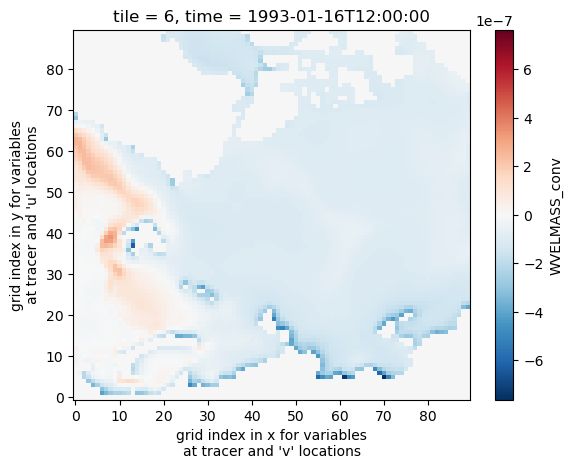

In [56]:
conv = (grid._ds["WVELMASS_conv"])
# conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 6).plot()

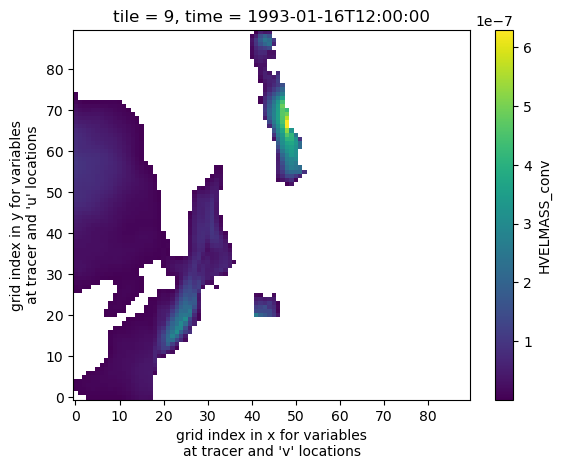

In [62]:
conv = (grid._ds["HVELMASS_conv"])
conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 9).plot()

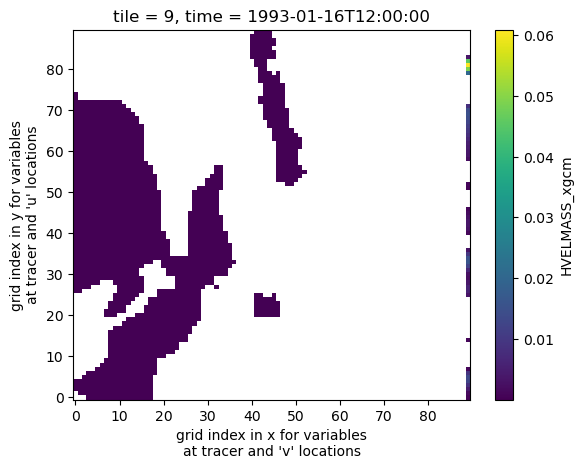

In [63]:
conv = (grid._ds["HVELMASS_xgcm"])
conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 9).plot()

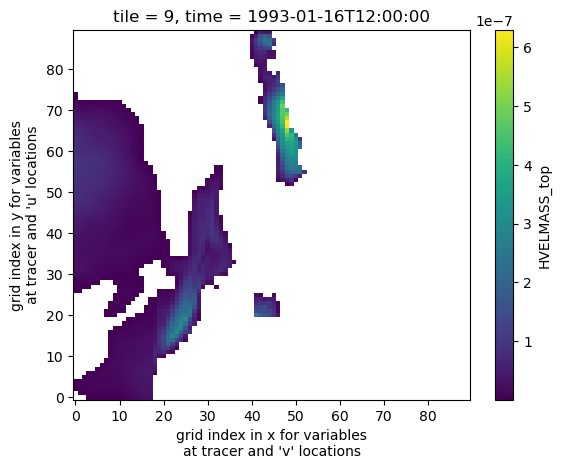

In [61]:
conv = (grid._ds["HVELMASS_top"])
conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 9).plot()

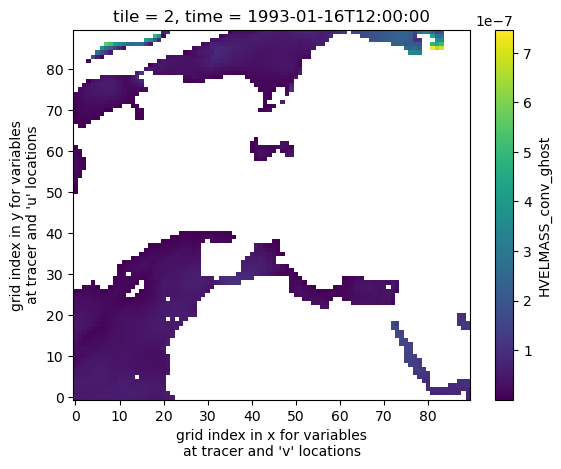

In [41]:
conv = (grid._ds["HVELMASS_conv_ghost"])
conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 2).plot()

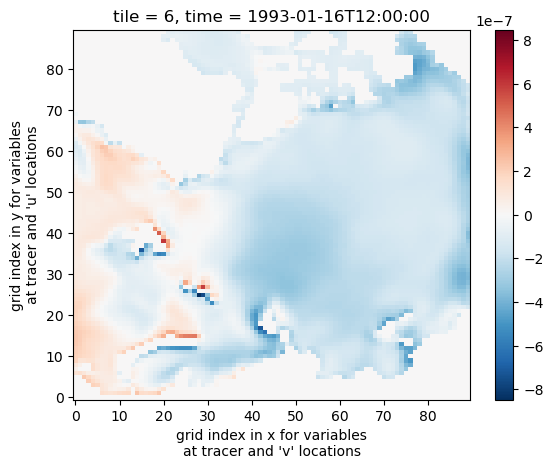

In [267]:
conv = (grid._ds["WVELMASS_conv"] + grid._ds["HVELMASS_conv"])
# conv = conv.where(np.abs(conv > 0.0))  

conv.isel(time = 0, tile = 6).plot()

In [24]:
deta_dt = grid._ds["ETAN_bounds"].diff("time_bounds").rename({"time_bounds":"time"}) / dt

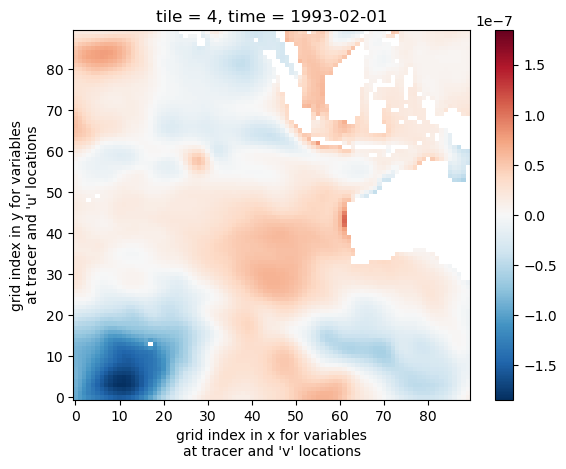

In [32]:
deta_dt.isel(time = 0, tile = 4).plot()